In [6]:
import requests
import io
from bs4 import BeautifulSoup
from PIL import Image
import matplotlib.pyplot as plt
import re
import base64

def get_spreadsheet_images(share_url: str):
    """
    公開されたスプレッドシートから画像を取得する
    
    Params:
      share_url (str): スプレッドシート共有リンクのURL
      
    Returns:
      list: 取得した画像のリスト（PIL.Image形式）
    """
    # スプレッドシートIDを抽出
    match_id = re.search(r"/d/([a-zA-Z0-9-_]+)", share_url)
    if not match_id:
        raise ValueError("スプレッドシートIDが共有リンクから抽出できませんでした。")
    sheet_id = match_id.group(1)
    
    # HTMLとして公開したURLを構築
    # 注意: スプレッドシートを「ウェブに公開」設定にする必要があります
    # html_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/pubhtml"
    html_url = share_url
    
    # HTMLを取得
    response = requests.get(html_url)
    response.raise_for_status()
    
    # BeautifulSoupでHTML解析
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # 画像要素を検索
    images = []
    
    # スプレッドシートのHTMLでは、画像はimg要素またはbackground-imageスタイルとして表示される
    # まずはimg要素を検索
    img_tags = soup.find_all('img')
    for img in img_tags:
        src = img.get('src')
        if src:
            try:
                img_response = requests.get(src)
                img_response.raise_for_status()
                image = Image.open(io.BytesIO(img_response.content))
                images.append(image)
            except Exception as e:
                print(f"画像の取得に失敗しました: {src}, エラー: {e}")
    
    # background-imageスタイルを持つ要素を検索
    elements_with_bg = soup.find_all(style=re.compile(r'background-image'))
    for element in elements_with_bg:
        style = element.get('style')
        # URLを抽出
        url_match = re.search(r'url\([\'"]?(.*?)[\'"]?\)', style)
        if url_match:
            src = url_match.group(1)
            try:
                if src.startswith('data:image'):
                    # Base64エンコードされた画像の場合
                    img_data = src.split(',', 1)[1]
                    image = Image.open(io.BytesIO(base64.b64decode(img_data)))
                else:
                    # 通常のURL
                    img_response = requests.get(src)
                    img_response.raise_for_status()
                    image = Image.open(io.BytesIO(img_response.content))
                images.append(image)
            except Exception as e:
                print(f"背景画像の取得に失敗しました: {src}, エラー: {e}")
    
    return images

def display_images(images):
    """取得した画像を表示する"""
    if not images:
        print("画像が見つかりませんでした。")
        return
    
    print(f"{len(images)}枚の画像が見つかりました。")
    
    # 画像を表示
    for i, img in enumerate(images):
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'スプレッドシート内の画像 {i+1}')
        plt.show()

1枚の画像が見つかりました。


c:\Users\kenta\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kenta\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kenta\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kenta\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kenta\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

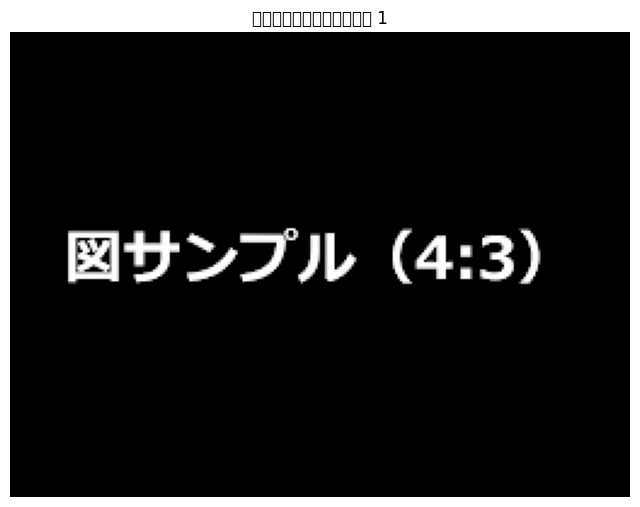

In [7]:
# 使用例
# スプレッドシートの共有リンク（ウェブに公開されている必要があります）
spreadsheet_url = "https://docs.google.com/spreadsheets/d/1ZlvRga55GwaF1M_-qsPGp4XKmkwUIAoR_JOPGQrFMTw/edit?usp=sharing"

# 画像を取得
try:
    images = get_spreadsheet_images(spreadsheet_url)
    display_images(images)
except Exception as e:
    print(f"エラーが発生しました: {e}")
    print("スプレッドシートが公開設定になっていることを確認してください。")